customers shape:  (532848, 2)
acq_orders shape: (508694, 2)
activity shape:   (2176168, 4)

--- Data Quality Audit: customers (Rows: 532,848) ---
Exact Duplicate Rows: 0


,Data Type,Non-Null Count,Null Count,Null %,Unique Count
customer_id,int64,532848,0,0.0,532848
customer_country,object,532848,0,0.0,2



--- Data Quality Audit: acq_orders (Rows: 508,694) ---
Exact Duplicate Rows: 0


,Data Type,Non-Null Count,Null Count,Null %,Unique Count
customer_id,int64,508694,0,0.0,508694
taxonomy_business_category_group,object,508694,0,0.0,7



--- Data Quality Audit: activity (Rows: 2,176,168) ---
Exact Duplicate Rows: 0


,Data Type,Non-Null Count,Null Count,Null %,Unique Count
customer_id,int64,2176168,0,0.0,512366
subscription_id,int64,2176168,0,0.0,1482002
from_date,object,2176168,0,0.0,2037
to_date,object,2176168,0,0.0,2011



--- Primary Key & Granularity Audits ---
customers: Unique customer_id vs Total: 532848 / 532848
acq_orders: Unique customer_id vs Total: 508694 / 508694

Activity date parsing failures: from_date=0, to_date=0
Inverted Date Ranges (to_date < from_date): 0
acq_orders orphans (missing from customers): 0
activity orphans (missing from customers):   0

--- Country Distribution ---
BRAZIL            296693
UNITED KINGDOM    236155
Name: customer_country, dtype: int64

--- Acquisition Category Distribution ---
Hair Loss Group        383273
Ed Group                73086
Weight Loss Group       41736
Other Group              7038
Sleep Group              2275
Trt Group                1285
Mental Health Group         1
Name: taxonomy_business_category_group, dtype: int64

--- Subscription Duration (Days) Descriptive Stats ---


,count,mean,std,min,25%,50%,75%,90%,max
taxonomy_business_category_group,,,,,,,,,
Ed Group,228180.0,84.5,137.5,0.0,20.0,34.0,90.0,184.0,1999.0
Hair Loss Group,1606598.0,117.5,125.8,0.0,42.0,90.0,158.0,266.0,1977.0
Mental Health Group,4.0,18.8,12.5,0.0,18.8,25.0,25.0,25.0,25.0
Other Group,20031.0,104.0,183.7,0.0,21.0,42.0,97.0,255.0,1804.0
Sleep Group,9145.0,102.6,198.3,0.0,25.0,32.0,88.0,220.6,1334.0
Trt Group,4445.0,23.0,41.0,0.0,1.0,7.0,27.0,76.0,434.0
Weight Loss Group,118566.0,32.1,48.1,0.0,1.0,13.0,44.0,90.0,759.0


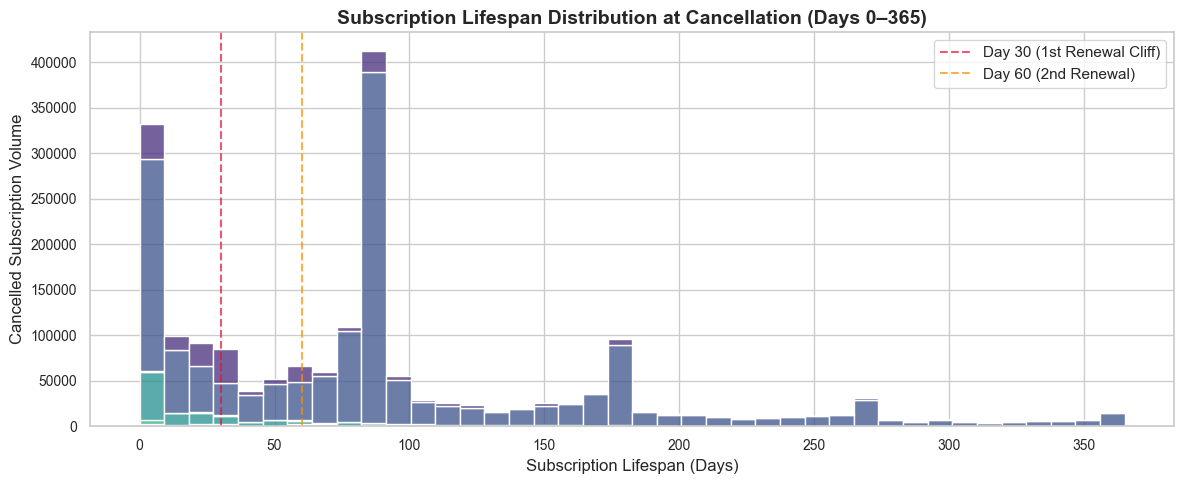

,Cohort Size,M+0,M+1,M+2,M+3,M+4,M+5,M+6
Cohort,,,,,,,,
2023-09,50479,100.0,94.0,86.3,75.8,42.9,38.5,32.9
2023-10,53686,100.0,94.8,88.0,77.7,41.4,37.8,32.7
2023-11,61560,100.0,95.0,88.5,77.2,41.5,37.5,32.8
2023-12,58038,100.0,94.4,87.2,76.6,42.3,38.8,33.1
2024-01,70578,100.0,94.0,87.5,77.0,44.1,40.5,35.9
2024-02,62610,100.0,93.8,85.8,74.8,43.2,39.7,0.0
2024-03,66010,100.0,93.8,85.6,72.7,42.8,0.0,0.0
2024-04,66672,100.0,93.5,85.1,74.0,0.0,0.0,0.0
2024-05,72326,100.0,93.1,85.8,0.0,0.0,0.0,0.0


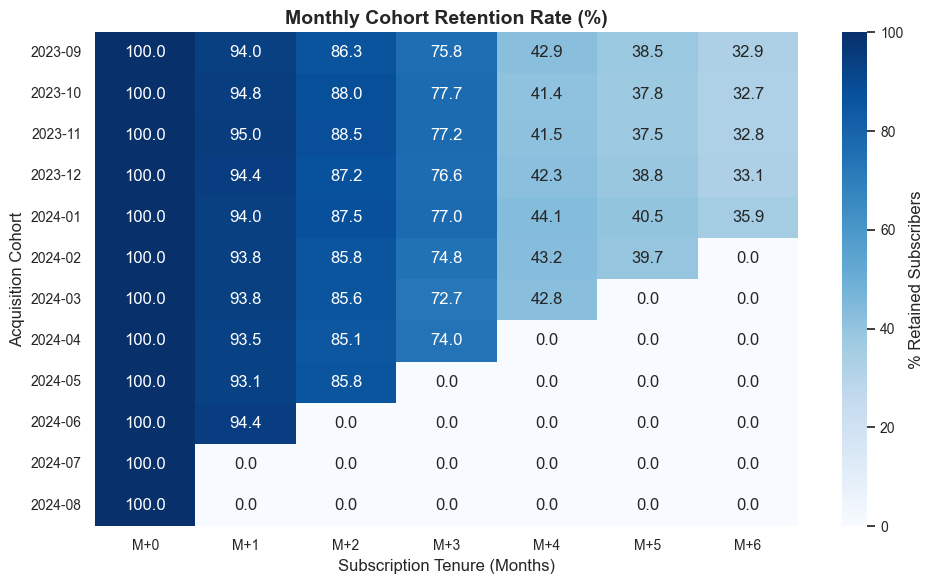

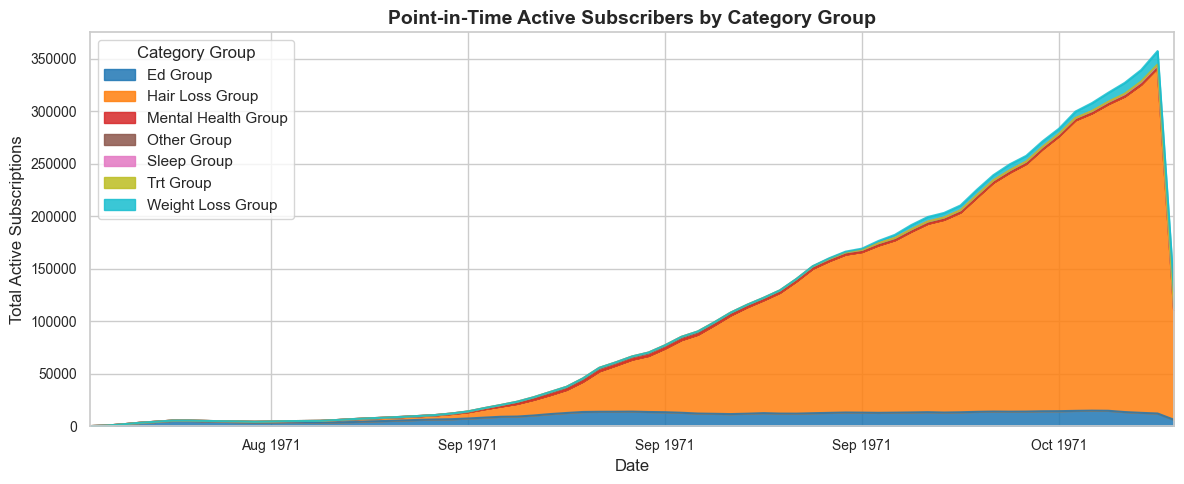

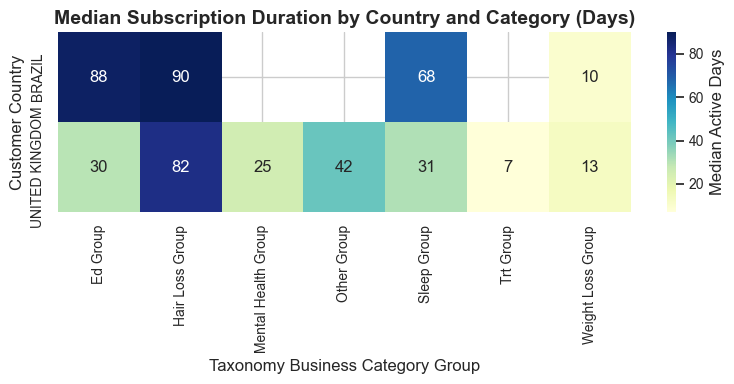


=== Executive KPI Summary ===


,Value
Total Customers,532848.00
Total Subscriptions,1482002.00
Currently Active Subscriptions,0.00
Active Subscription Rate (%),0.00
Overall Median Lifespan (Days),80.00
Day 30 Early Churn Rate (%),35.38


In [4]:
# ==============================================================================
# VOY / MANUAL: EXPLORATORY DATA ANALYSIS & DATA AUDIT
# Datasets: customers.csv, acq_orders.csv, activity.csv
# ==============================================================================

# %% [Cell 1] Import Libraries & Configuration
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Visual formatting setup
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update(
    {
        "figure.figsize": (12, 6),
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.dpi": 100,
    }
)

# %% [Cell 2] Load Datasets
customers_raw = pd.read_csv("C:\\Users\\jcstr\\Downloads\\customers.csv")
acq_orders_raw = pd.read_csv("C:\\Users\\jcstr\\Downloads\\acq_orders.csv")
activity_raw = pd.read_csv("C:\\Users\\jcstr\\Downloads\\activity.csv")

print(f"customers shape:  {customers_raw.shape}")
print(f"acq_orders shape: {acq_orders_raw.shape}")
print(f"activity shape:   {activity_raw.shape}")

# %% [Cell 3] Data Overview & Quality Audit Helper
def audit_dataframe(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Returns a structural data quality and completeness summary."""
    summary = pd.DataFrame(
        {
            "Data Type": df.dtypes,
            "Non-Null Count": df.notnull().sum(),
            "Null Count": df.isnull().sum(),
            "Null %": (df.isnull().sum() / len(df) * 100).round(2),
            "Unique Count": df.nunique(),
        }
    )
    print(f"\n--- Data Quality Audit: {name} (Rows: {len(df):,}) ---")
    print(f"Exact Duplicate Rows: {df.duplicated().sum()}")
    return summary

display(audit_dataframe(customers_raw, "customers"))
display(audit_dataframe(acq_orders_raw, "acq_orders"))
display(audit_dataframe(activity_raw, "activity"))

# %% [Cell 4] Integrity Checks & Dirty Data Profiling
# 1. Primary Key Uniqueness
print("\n--- Primary Key & Granularity Audits ---")
print(f"customers: Unique customer_id vs Total: {customers_raw['customer_id'].nunique()} / {len(customers_raw)}")
print(f"acq_orders: Unique customer_id vs Total: {acq_orders_raw['customer_id'].nunique()} / {len(acq_orders_raw)}")

# 2. Date Parsing & Temporal Logic Checks
activity_clean = activity_raw.copy()
activity_clean["from_date"] = pd.to_datetime(activity_clean["from_date"], errors="coerce")
activity_clean["to_date"] = pd.to_datetime(activity_clean["to_date"], errors="coerce")

# Check for unparseable dates
invalid_from = activity_clean["from_date"].isnull().sum()
invalid_to = (activity_clean["to_date"].isnull() & activity_raw["to_date"].notnull()).sum()
print(f"\nActivity date parsing failures: from_date={invalid_from}, to_date={invalid_to}")

# Inverted Date Check (to_date < from_date)
inverted_dates = activity_clean[activity_clean["to_date"] < activity_clean["from_date"]]
print(f"Inverted Date Ranges (to_date < from_date): {len(inverted_dates)}")

# 3. Referential Integrity (Orphan Records)
cust_ids = set(customers_raw["customer_id"])
acq_orphans = acq_orders_raw[~acq_orders_raw["customer_id"].isin(cust_ids)]
act_orphans = activity_clean[~activity_clean["customer_id"].isin(cust_ids)]
print(f"acq_orders orphans (missing from customers): {len(acq_orphans)}")
print(f"activity orphans (missing from customers):   {len(act_orphans)}")

# %% [Cell 5] Categorical Sanitisation & Descriptive Profiles
# Clean string columns
customers = customers_raw.copy()
customers["customer_country"] = customers["customer_country"].astype(str).str.strip().str.upper()

acq_orders = acq_orders_raw.copy()
acq_orders["taxonomy_business_category_group"] = (
    acq_orders["taxonomy_business_category_group"].astype(str).str.strip().str.title()
)

print("\n--- Country Distribution ---")
print(customers["customer_country"].value_counts(dropna=False))

print("\n--- Acquisition Category Distribution ---")
print(acq_orders["taxonomy_business_category_group"].value_counts(dropna=False))

# %% [Cell 6] Feature Engineering for Lifespan & Subscription Metrics
# Define active state and duration (in days)
activity_clean["is_active"] = activity_clean["to_date"].isnull()

# Compute lifespan in days (using max snapshot date for active subscriptions)
snapshot_date = activity_clean["from_date"].max()
activity_clean["effective_end_date"] = activity_clean["to_date"].fillna(snapshot_date)
activity_clean["duration_days"] = (
    activity_clean["effective_end_date"] - activity_clean["from_date"]
).dt.days

# Join customer dimension and acquisition taxonomy
master_df = activity_clean.merge(
    customers, on="customer_id", how="left"
).merge(
    acq_orders, on="customer_id", how="left"
)

# Descriptive stats on subscription duration
print("\n--- Subscription Duration (Days) Descriptive Stats ---")
display(
    master_df.groupby("taxonomy_business_category_group")["duration_days"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9])
    .round(1)
)

# %% [Cell 7] Visualisation 1: Churn Hazard & Duration Distribution
fig, ax = plt.subplots(figsize=(12, 5))

completed_subs = master_df[~master_df["is_active"]]
sns.histplot(
    data=completed_subs,
    x="duration_days",
    hue="taxonomy_business_category_group",
    multiple="stack",
    bins=40,
    binrange=(0, 365),
    palette="viridis",
    ax=ax,
)

ax.set_title("Subscription Lifespan Distribution at Cancellation (Days 0–365)")
ax.set_xlabel("Subscription Lifespan (Days)")
ax.set_ylabel("Cancelled Subscription Volume")
ax.axvline(30, color="crimson", linestyle="--", alpha=0.7, label="Day 30 (1st Renewal Cliff)")
ax.axvline(60, color="darkorange", linestyle="--", alpha=0.7, label="Day 60 (2nd Renewal)")
ax.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

# %% [Cell 8] Visualisation 2: Monthly Cohort Retention Matrix (M0–M6)
# Build Cohort Analysis Table
master_df["cohort_month"] = master_df["from_date"].dt.to_period("M")
master_df["churn_month"] = master_df["to_date"].dt.to_period("M")

# Filter to primary historical cohorts with sufficient maturity
cohort_data = []
all_cohorts = sorted(master_df["cohort_month"].dropna().unique())

for cohort in all_cohorts[-12:]:  # Last 12 cohorts
    cohort_subs = master_df[master_df["cohort_month"] == cohort]
    total_acquired = len(cohort_subs)
    if total_acquired == 0:
        continue
    
    retention_row = {"Cohort": str(cohort), "Cohort Size": total_acquired}
    for m in range(7):
        target_month = cohort + m
        # Active in target month if started on/before and (to_date is null or ended after target month)
        active_count = len(
            cohort_subs[
                (cohort_subs["cohort_month"] <= target_month)
                & (cohort_subs["churn_month"].isnull() | (cohort_subs["churn_month"] >= target_month))
            ]
        )
        retention_row[f"M+{m}"] = round((active_count / total_acquired) * 100, 1)
    cohort_data.append(retention_row)

retention_matrix = pd.DataFrame(cohort_data).set_index("Cohort")
display(retention_matrix)

# Heatmap of Cohort Retention
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    retention_matrix.drop(columns=["Cohort Size"]),
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "% Retained Subscribers"},
    ax=ax,
)
ax.set_title("Monthly Cohort Retention Rate (%)")
ax.set_xlabel("Subscription Tenure (Months)")
ax.set_ylabel("Acquisition Cohort")
plt.tight_layout()
plt.show()

# %% [Cell 9] Visualisation 3: Active Subscribers Evolution Over Time
# Generate monthly date spine to evaluate point-in-time active subscriptions
date_range = pd.date_range(
    start=master_df["from_date"].min(),
    end=master_df["from_date"].max(),
    freq="MS",
)

spine_records = []
for dt in date_range:
    for cat, group in master_df.groupby("taxonomy_business_category_group"):
        active_count = (
            (group["from_date"] <= dt)
            & (group["to_date"].isnull() | (group["to_date"] > dt))
        ).sum()
        spine_records.append({"Month": dt, "Category": cat, "Active Subscribers": active_count})

active_evolution = pd.DataFrame(spine_records)

fig, ax = plt.subplots(figsize=(12, 5))
pivot_evolution = active_evolution.pivot(index="Month", columns="Category", values="Active Subscribers").fillna(0)
pivot_evolution.plot(kind="area", stacked=True, colormap="tab10", alpha=0.85, ax=ax)

ax.set_title("Point-in-Time Active Subscribers by Category Group")
ax.set_xlabel("Date")
ax.set_ylabel("Total Active Subscriptions")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend(title="Category Group", loc="upper left")
plt.tight_layout()
plt.show()

# %% [Cell 10] Visualisation 4: Category vs Market Adherence Heatmap
pivot_adherence = master_df.pivot_table(
    index="customer_country",
    columns="taxonomy_business_category_group",
    values="duration_days",
    aggfunc="median",
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    pivot_adherence,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    cbar_kws={"label": "Median Active Days"},
    ax=ax,
)
ax.set_title("Median Subscription Duration by Country and Category (Days)")
ax.set_xlabel("Taxonomy Business Category Group")
ax.set_ylabel("Customer Country")
plt.tight_layout()
plt.show()

# %% [Cell 11] Summary Table of Derived Commercial KPIs
kpi_summary = pd.DataFrame(
    {
        "Total Customers": [customers["customer_id"].nunique()],
        "Total Subscriptions": [activity_clean["subscription_id"].nunique()],
        "Currently Active Subscriptions": [activity_clean["is_active"].sum()],
        "Active Subscription Rate (%)": [
            round((activity_clean["is_active"].sum() / len(activity_clean)) * 100, 2)
        ],
        "Overall Median Lifespan (Days)": [
            round(master_df[~master_df["is_active"]]["duration_days"].median(), 1)
        ],
        "Day 30 Early Churn Rate (%)": [
            round(
                (len(master_df[(~master_df["is_active"]) & (master_df["duration_days"] <= 31)]) / len(master_df)) * 100,
                2,
            )
        ],
    }
)

print("\n=== Executive KPI Summary ===")
display(kpi_summary.T.rename(columns={0: "Value"}))

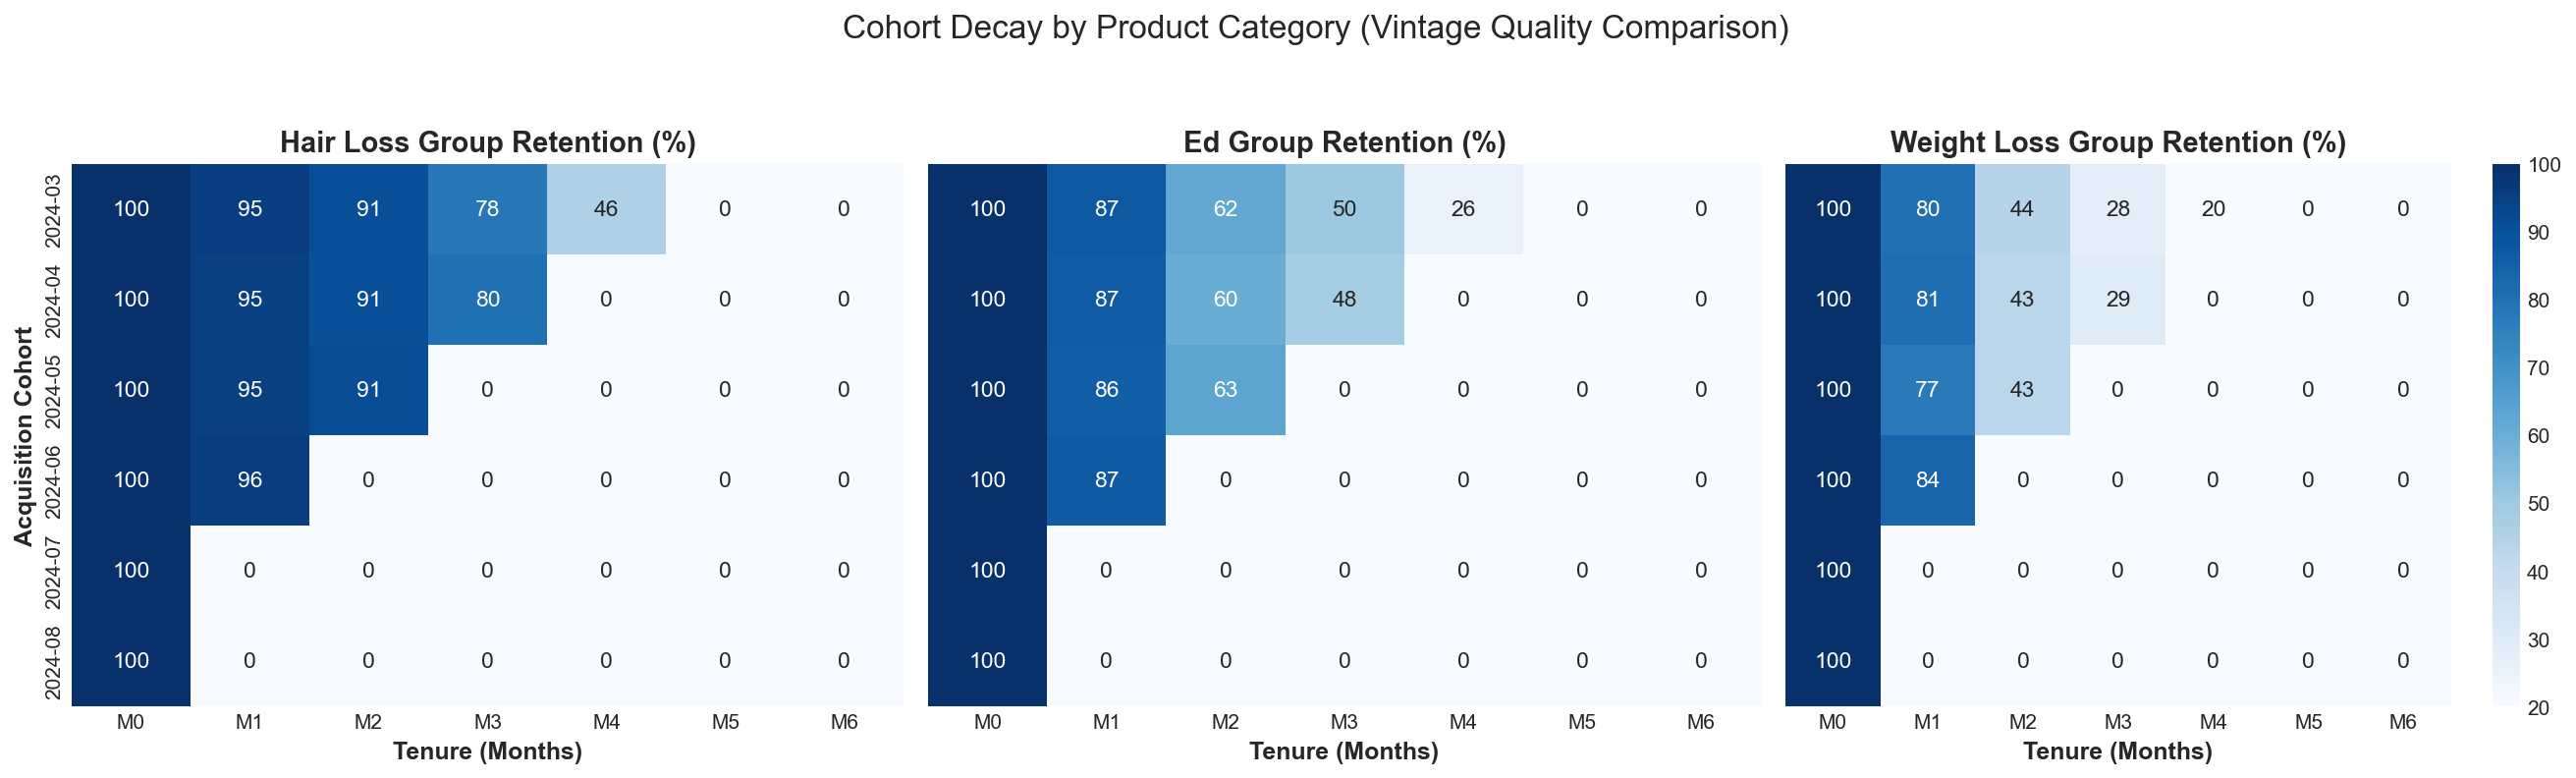

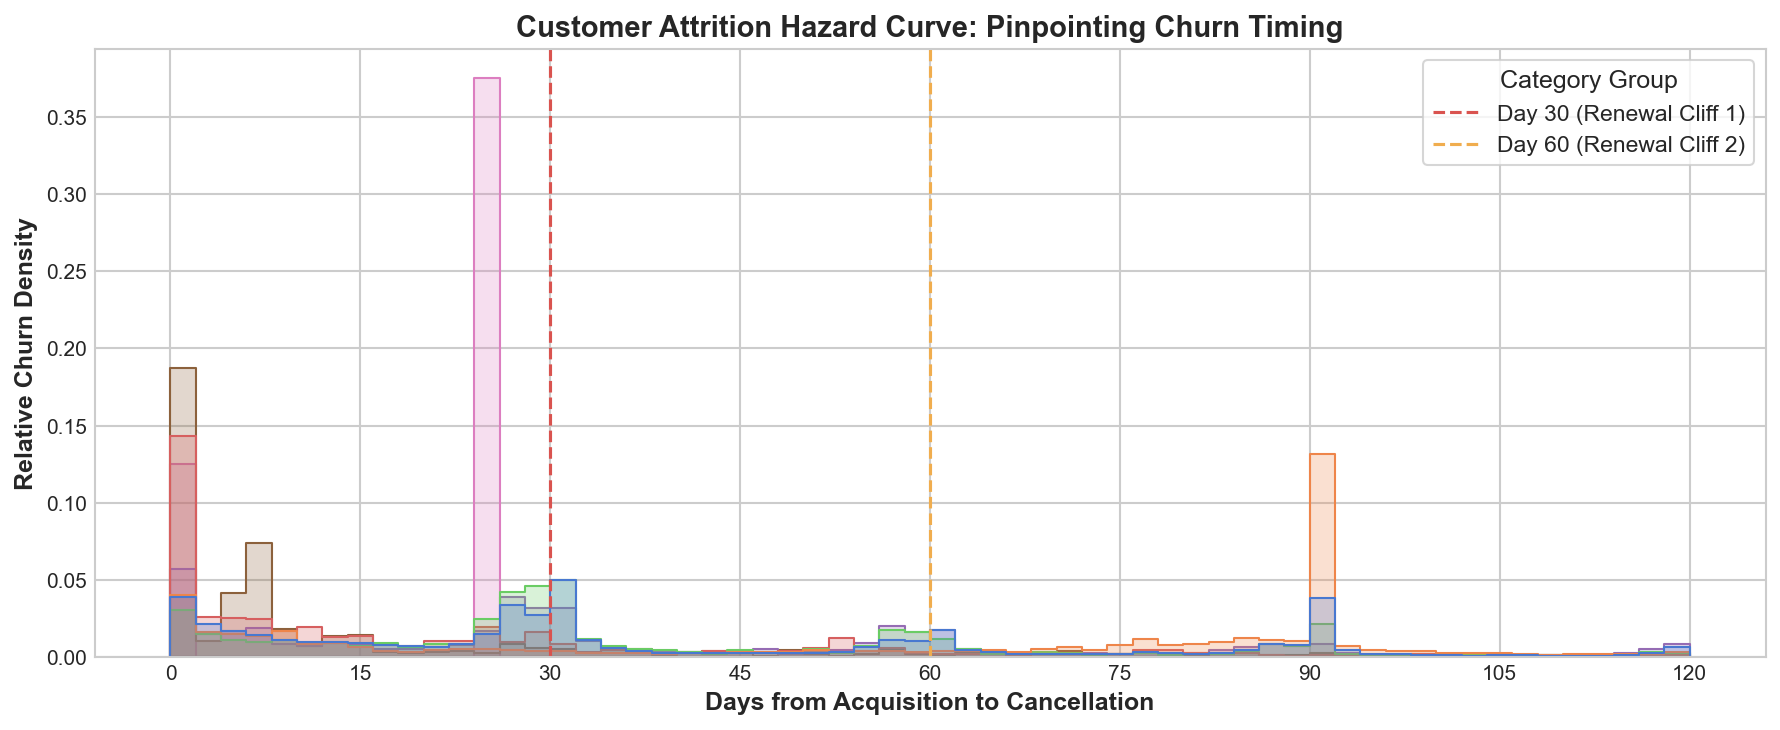

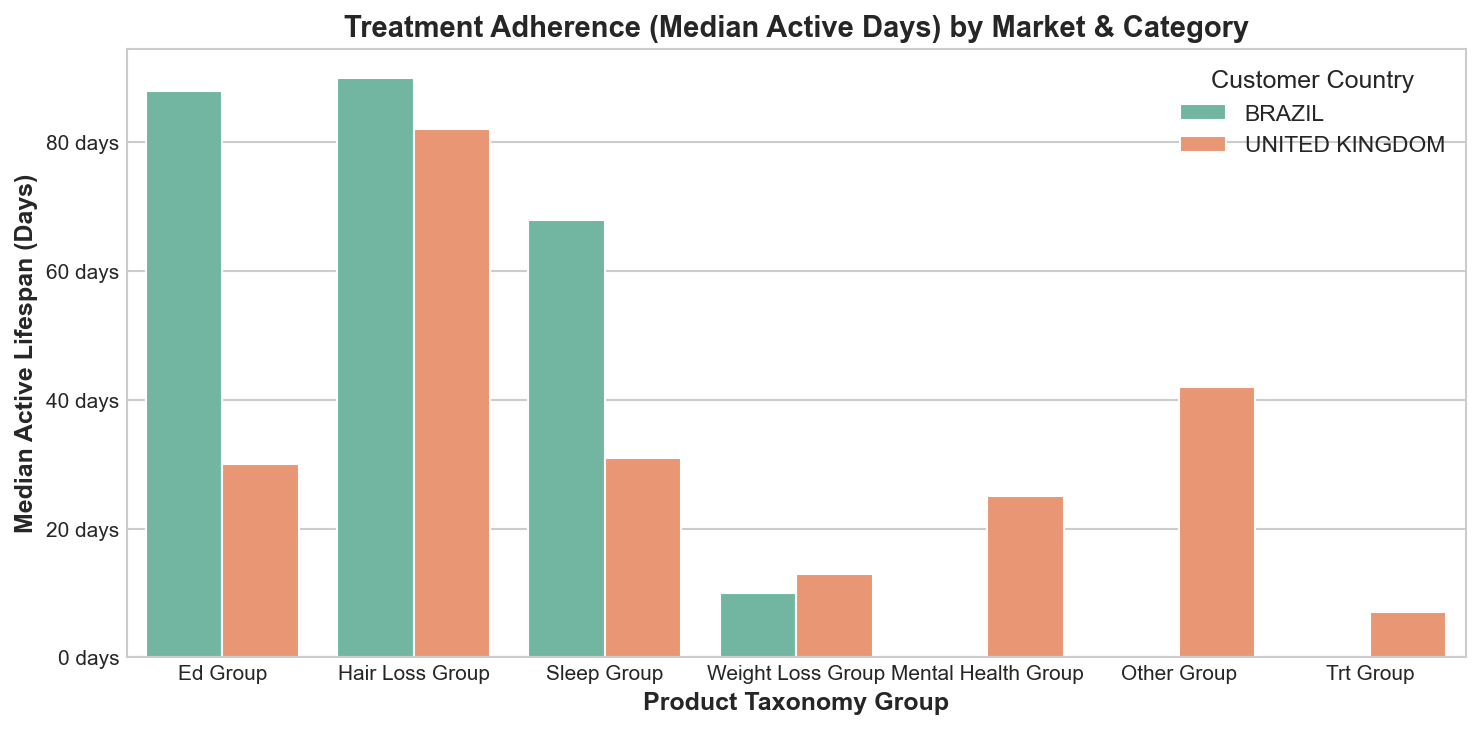

In [6]:
# %% [1] Executive Setup & Visual Standards
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

# Board-grade styling standards
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelweight": "semibold",
    "figure.titlesize": 16,
    "figure.dpi": 150,
})

# %% [2] Ingestion & Dimensional Staging
# %% [Cell 2] Load Datasets
customers_raw = pd.read_csv("C:\\Users\\jcstr\\Downloads\\customers.csv")
acq_orders_raw = pd.read_csv("C:\\Users\\jcstr\\Downloads\\acq_orders.csv")
activity_raw = pd.read_csv("C:\\Users\\jcstr\\Downloads\\activity.csv")

# Standardise country and category dimensions
customers_df = customers_raw.copy()
acq_orders_df = acq_orders_raw.copy()
activity_df = activity_raw.copy()

customers_df["customer_country"] = customers_df["customer_country"].str.strip().str.upper()
acq_orders_df["category"] = acq_orders_df["taxonomy_business_category_group"].str.strip().str.title()

# Clean date fields and establish subscription state
activity_df["from_date"] = pd.to_datetime(activity_df["from_date"], errors="coerce")
activity_df["to_date"] = pd.to_datetime(activity_df["to_date"], errors="coerce")
activity_df["is_active"] = activity_df["to_date"].isnull()

# Anchor snapshot to latest active date in log
snapshot_date = activity_df["from_date"].max()
activity_df["effective_end"] = activity_df["to_date"].fillna(snapshot_date)
activity_df["tenure_days"] = (activity_df["effective_end"] - activity_df["from_date"]).dt.days

# Join into single analytical master dataset
df = activity_df.merge(customers_df, on="customer_id", how="left") \
                .merge(acq_orders_df, on="customer_id", how="left")

# %% [3] Analysis 1: M0–M6 Cohort Retention by Category
df["cohort_month"] = df["from_date"].dt.to_period("M")
df["churn_month"] = df["to_date"].dt.to_period("M")

# Build cohort matrix for top categories
categories = df["category"].value_counts().head(3).index.tolist()
fig, axes = plt.subplots(1, len(categories), figsize=(18, 5), sharey=True)

for i, cat in enumerate(categories):
    cat_df = df[df["category"] == cat]
    recent_cohorts = sorted(cat_df["cohort_month"].dropna().unique())[-6:]
    
    matrix = []
    for cohort in recent_cohorts:
        c_subs = cat_df[cat_df["cohort_month"] == cohort]
        base_size = len(c_subs)
        row = [100.0]
        for m in range(1, 7):
            target = cohort + m
            retained = len(c_subs[(c_subs["churn_month"].isnull()) | (c_subs["churn_month"] >= target)])
            row.append(round((retained / base_size) * 100, 1) if base_size > 0 else 0)
        matrix.append(row)
    
    ret_df = pd.DataFrame(matrix, index=[str(c) for c in recent_cohorts], columns=[f"M{m}" for m in range(7)])
    sns.heatmap(ret_df, annot=True, fmt=".0f", cmap="Blues", cbar=(i == len(categories)-1), ax=axes[i], vmin=20, vmax=100)
    axes[i].set_title(f"{cat} Retention (%)")
    axes[i].set_xlabel("Tenure (Months)")
    if i == 0:
        axes[i].set_ylabel("Acquisition Cohort")

plt.suptitle("Cohort Decay by Product Category (Vintage Quality Comparison)", y=1.05)
plt.tight_layout()
plt.show()

# %% [4] Analysis 2: Churn Hazard Curve (Days 0–120)
fig, ax = plt.subplots(figsize=(12, 5))

completed = df[~df["is_active"] & (df["tenure_days"] <= 120)]
sns.histplot(
    data=completed,
    x="tenure_days",
    hue="category",
    element="step",
    stat="density",
    common_norm=False,
    bins=60,
    ax=ax
)

ax.set_title("Customer Attrition Hazard Curve: Pinpointing Churn Timing")
ax.set_xlabel("Days from Acquisition to Cancellation")
ax.set_ylabel("Relative Churn Density")
ax.axvline(30, color="#d9534f", linestyle="--", linewidth=1.5, label="Day 30 (Renewal Cliff 1)")
ax.axvline(60, color="#f0ad4e", linestyle="--", linewidth=1.5, label="Day 60 (Renewal Cliff 2)")
ax.xaxis.set_major_locator(plt.MultipleLocator(15))
ax.legend(title="Category Group", frameon=True)
plt.tight_layout()
plt.show()

# %% [5] Analysis 3: Market Durability & Median Subscriber Lifespan
market_perf = df.groupby(["customer_country", "category"]).agg(
    total_subs=("subscription_id", "count"),
    active_subs=("is_active", "sum"),
    median_days=("tenure_days", "median")
).reset_index()

market_perf["active_rate_pct"] = (market_perf["active_subs"] / market_perf["total_subs"]) * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=market_perf,
    x="category",
    y="median_days",
    hue="customer_country",
    palette="Set2",
    ax=ax
)

ax.set_title("Treatment Adherence (Median Active Days) by Market & Category")
ax.set_xlabel("Product Taxonomy Group")
ax.set_ylabel("Median Active Lifespan (Days)")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:.0f} days"))
ax.legend(title="Customer Country", loc="upper right")
plt.tight_layout()
plt.show()